In [1]:
import sys, os
repo_path = os.path.abspath('~/ukbcmr2021/DeepCMR') # absolute path to the repo folder as it resides on the server
if not repo_path in sys.path: sys.path.append(repo_path) 

In [2]:
import glob 
import numpy as np
import pandas as pd
import nibabel as nib
import seaborn as sns
from utils import metrics
import matplotlib.pylab as plt

%config Completer.use_jedi = False

# Determine Inter-Observer Variability 

The purpose of these analyses is to determine when we can stop increasing the training dataset or improving the learning model, i.e., we would like to have an accuracy comparable to the inter-observer variability. 

### Load segmenations and calculate areas 

In [3]:
data_folder = '{deepcmr_data_root}/OrthancDicomStorage-PracticeNiftis'

In [4]:
PatientPaths = glob.glob(os.path.join(data_folder, '*_gt.nii.gz'))

In [6]:
area_readings = {'PatientName':[], 'Area_cm2':[], 'Phase':[], 'Reader':[]}

for PatientPath in sorted(PatientPaths):
    PatientName = ' '.join(os.path.basename(PatientPath).split(' ')[:4]).strip('^Bio')
    
    M_nifti = nib.load(PatientPath)
    M = M_nifti.get_fdata().squeeze()
    try:
        reader = int(os.path.basename(PatientPath).split('[R')[1].split(']')[0])
    except:
        print(os.path.basename(PatientPath))
    for phase in range(M.shape[-1]):
        area = metrics.get_area_cm2(M=M[:,:,phase], pixel_spacing_mm=M_nifti.header.get_zooms()[:2])
        
        area_readings['PatientName'] += [PatientName]
        area_readings['Area_cm2'] += [area]
        area_readings['Phase'] += [phase]
        area_readings['Reader'] += [reader]

area_readings = pd.DataFrame(area_readings)

### Calculate distensibility for subjects with annotations from two different users 

In [ ]:
distensibility_readings = {'PatientName':[], 'Distensibility':[], 'Reader':[]}

for PatientName in sorted(area_readings.PatientName.unique()):
    Patient_df = area_readings[area_readings.PatientName==PatientName]
    if len(Patient_df.Reader.unique()) == 2:
        PatientName = Patient_df.PatientName.unique().item()
        area_1 = list(Patient_df[Patient_df.Reader==1].Area_cm2)
        area_2 = list(Patient_df[Patient_df.Reader==2].Area_cm2)
        
        pmin1, amin1 = np.argmin(area_1), np.min(area_1)
        pmax1, amax1 = np.argmax(area_1), np.max(area_1)
        pmin2, amin2 = np.argmin(area_2), np.min(area_2)
        pmax2, amax2 = np.argmax(area_2), np.max(area_2)
        
        PA_distensibility_1 =  (amax1-amin1)/amin1
        PA_distensibility_2 =  (amax2-amin2)/amin2
        
        for distensibility, reader in zip([PA_distensibility_1, PA_distensibility_2],[1,2]):
            distensibility_readings['PatientName'] += [PatientName]
            distensibility_readings['Distensibility'] += [distensibility]
            distensibility_readings['Reader'] += [reader]
        
        bias = 100*(PA_distensibility_2-PA_distensibility_1)
        MAE = np.abs(bias)
        plt.plot(area_1, label='Reader 1', color='blue'); plt.title('%s : bias = %.3f  MAE = %.3f'%(PatientName, bias, MAE))
        plt.plot(area_2, label='Reader 2', color='orange')
        plt.scatter([pmin1, pmax1],[amin1, amax1], color='blue')
        plt.scatter([pmin2, pmax2],[amin2, amax2], color='orange')
        plt.legend()
        plt.show()
        
distensibility_readings = pd.DataFrame(distensibility_readings)

(0.0, 1.0)

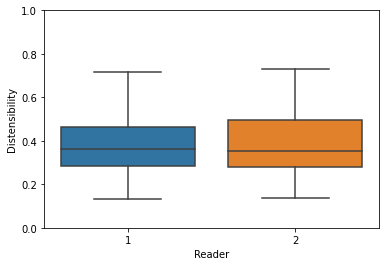

In [13]:
sns.boxplot(data=distensibility_readings, x='Reader', y='Distensibility')
plt.ylim(0, 1)

### Evaluate results 

In [17]:
def get_bias_and_mae(rdf1,rdf2):
    x = np.array(rdf1.Distensibility)
    y = np.array(rdf2.Distensibility)
    bias = 100*(y - x)
    return bias, np.abs(bias)

In [18]:
rc, arc = get_bias_and_mae(distensibility_readings[distensibility_readings.Reader==1],
                              distensibility_readings[distensibility_readings.Reader==2])

In [28]:
print('Bias %.2f%% ± %.2f%%'%(np.mean(rc), np.std(rc)))
print('Mean Absolute Difference %.2f%% ± %.2f%%'%(np.mean(arc), np.std(arc)))

Bias -0.07% ± 7.75%
Mean Absolute Difference 5.78% ± 5.17%


Text(0, 0.5, 'Mean Absolute Difference (%)')

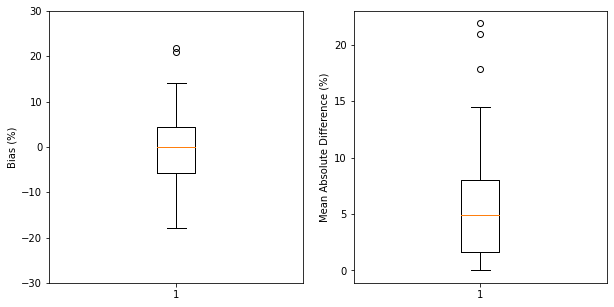

In [22]:
plt.figure(figsize=(10,5))
plt.subplot(121); plt.boxplot(rc); plt.ylabel('Bias (%)'); plt.ylim(-30,30)
plt.subplot(122); plt.boxplot(arc); plt.ylabel('Mean Absolute Difference (%)')